In [1]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns

mpl.rcParams.update({
    "font.size": 14,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.dpi": 150,
})

In [2]:

df = pd.read_csv("/content/ObesityDataSet_raw_and_data_sinthetic.csv")
df["is_fit"] = np.where(df["NObeyesdad"] == "Normal_Weight", "Fit", "Not-Fit")

print("Shape:", df.shape)
print("\nClass balance:")
print(df["is_fit"].value_counts())
print(f"\nTotal n = {len(df)}  |  Fit prevalence = {(df['is_fit']=='Fit').mean()*100:.1f}%")

df.head()

Shape: (2111, 19)

Class balance:
is_fit
Not-Fit    1824
Fit         287
Name: count, dtype: int64

Total n = 2111  |  Fit prevalence = 13.6%


,ID,Gender,Age,Height,Weight,family_history_with_overweight,FAVC,FCVC,NCP,CAEC,SMOKE,CH2O,SCC,FAF,TUE,CALC,MTRANS,NObeyesdad,is_fit
0,1,Female,21,1.62,64.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,0.0,1.0,no,Public_Transportation,Normal_Weight,Fit
1,2,Female,21,1.52,56.0,yes,no,3.0,3.0,Sometimes,yes,3.0,yes,3.0,0.0,Sometimes,Public_Transportation,Normal_Weight,Fit
2,3,Male,23,1.80,77.0,yes,no,2.0,3.0,Sometimes,no,2.0,no,2.0,1.0,Frequently,Public_Transportation,Normal_Weight,Fit
3,4,Male,27,1.80,87.0,no,no,3.0,3.0,Sometimes,no,2.0,no,2.0,0.0,Frequently,Walking,Overweight_Level_I,Not-Fit
4,5,Male,22,1.78,89.8,no,no,2.0,1.0,Sometimes,no,2.0,no,0.0,0.0,Sometimes,Public_Transportation,Overweight_Level_II,Not-Fit


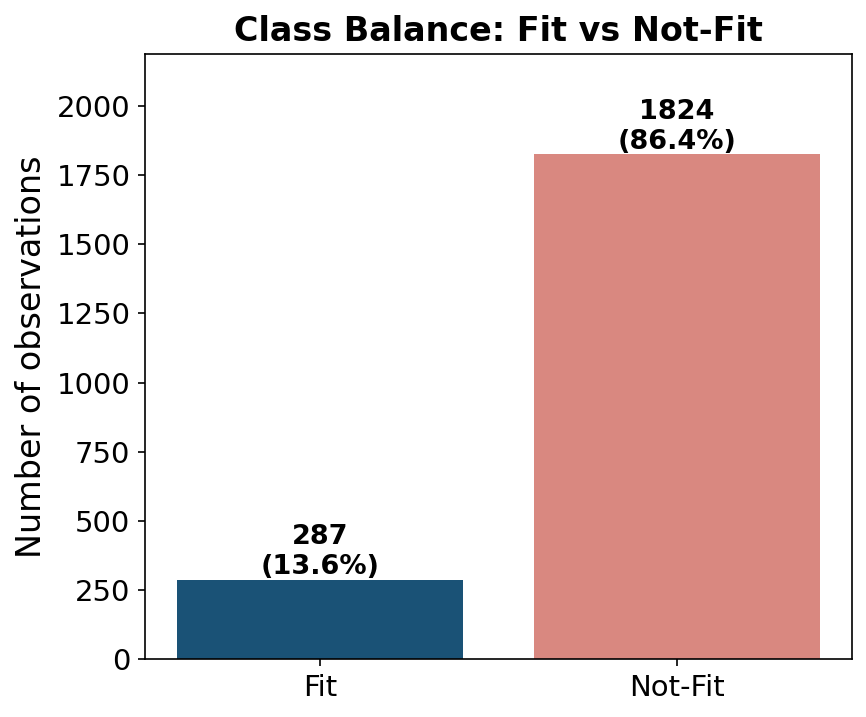

In [3]:
PALETTE = {"Fit": "#1A5276", "Not-Fit": "#D98880"}

fig, ax = plt.subplots(figsize=(6, 5))
counts = df["is_fit"].value_counts().reindex(["Fit", "Not-Fit"])
bars = ax.bar(counts.index, counts.values, color=[PALETTE["Fit"], PALETTE["Not-Fit"]])
for bar, val in zip(bars, counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 20, f"{val}\n({val/len(df)*100:.1f}%)",
            ha="center", fontsize=13, fontweight="bold")
ax.set_ylabel("Number of observations")
ax.set_title("Class Balance: Fit vs Not-Fit", fontweight="bold")
ax.set_ylim(0, max(counts.values) * 1.2)
fig.tight_layout()
fig.savefig("fig4_eda_class_balance.png", bbox_inches="tight")
plt.show()

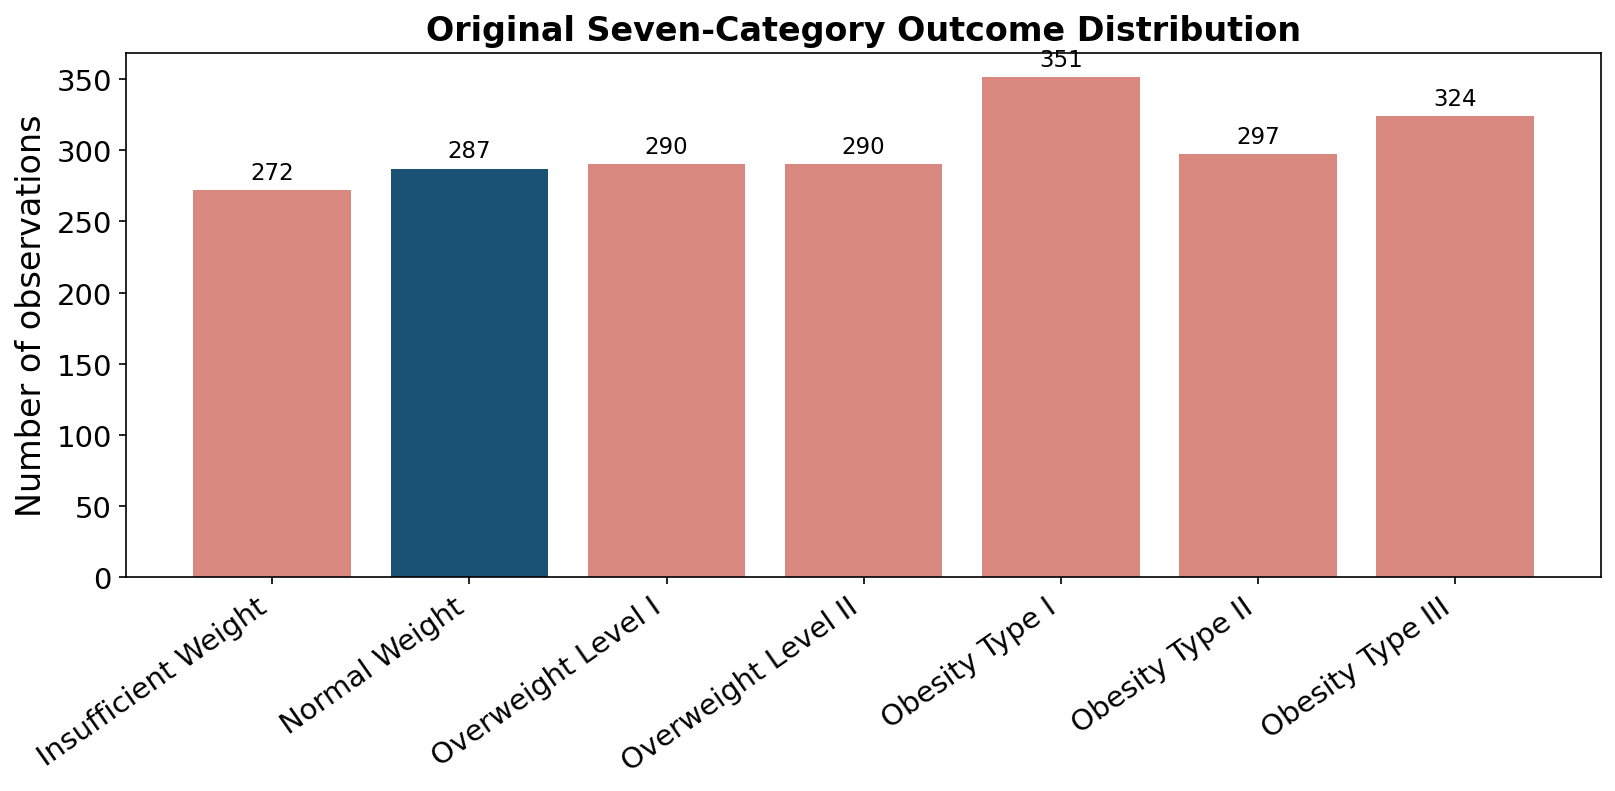

In [4]:
order = ["Insufficient_Weight", "Normal_Weight", "Overweight_Level_I", "Overweight_Level_II",
         "Obesity_Type_I", "Obesity_Type_II", "Obesity_Type_III"]

fig, ax = plt.subplots(figsize=(11, 5.5))
counts7 = df["NObeyesdad"].value_counts().reindex(order)
colors7 = ["#D98880" if c != "Normal_Weight" else "#1A5276" for c in order]
bars = ax.bar(range(len(order)), counts7.values, color=colors7)
ax.set_xticks(range(len(order)))
ax.set_xticklabels([c.replace("_", " ") for c in order], rotation=35, ha="right")
for bar, val in zip(bars, counts7.values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 8, str(val), ha="center", fontsize=11)
ax.set_ylabel("Number of observations")
ax.set_title("Original Seven-Category Outcome Distribution", fontweight="bold")
fig.tight_layout()
fig.savefig("fig4_eda_seven_category.png", bbox_inches="tight")
plt.show()

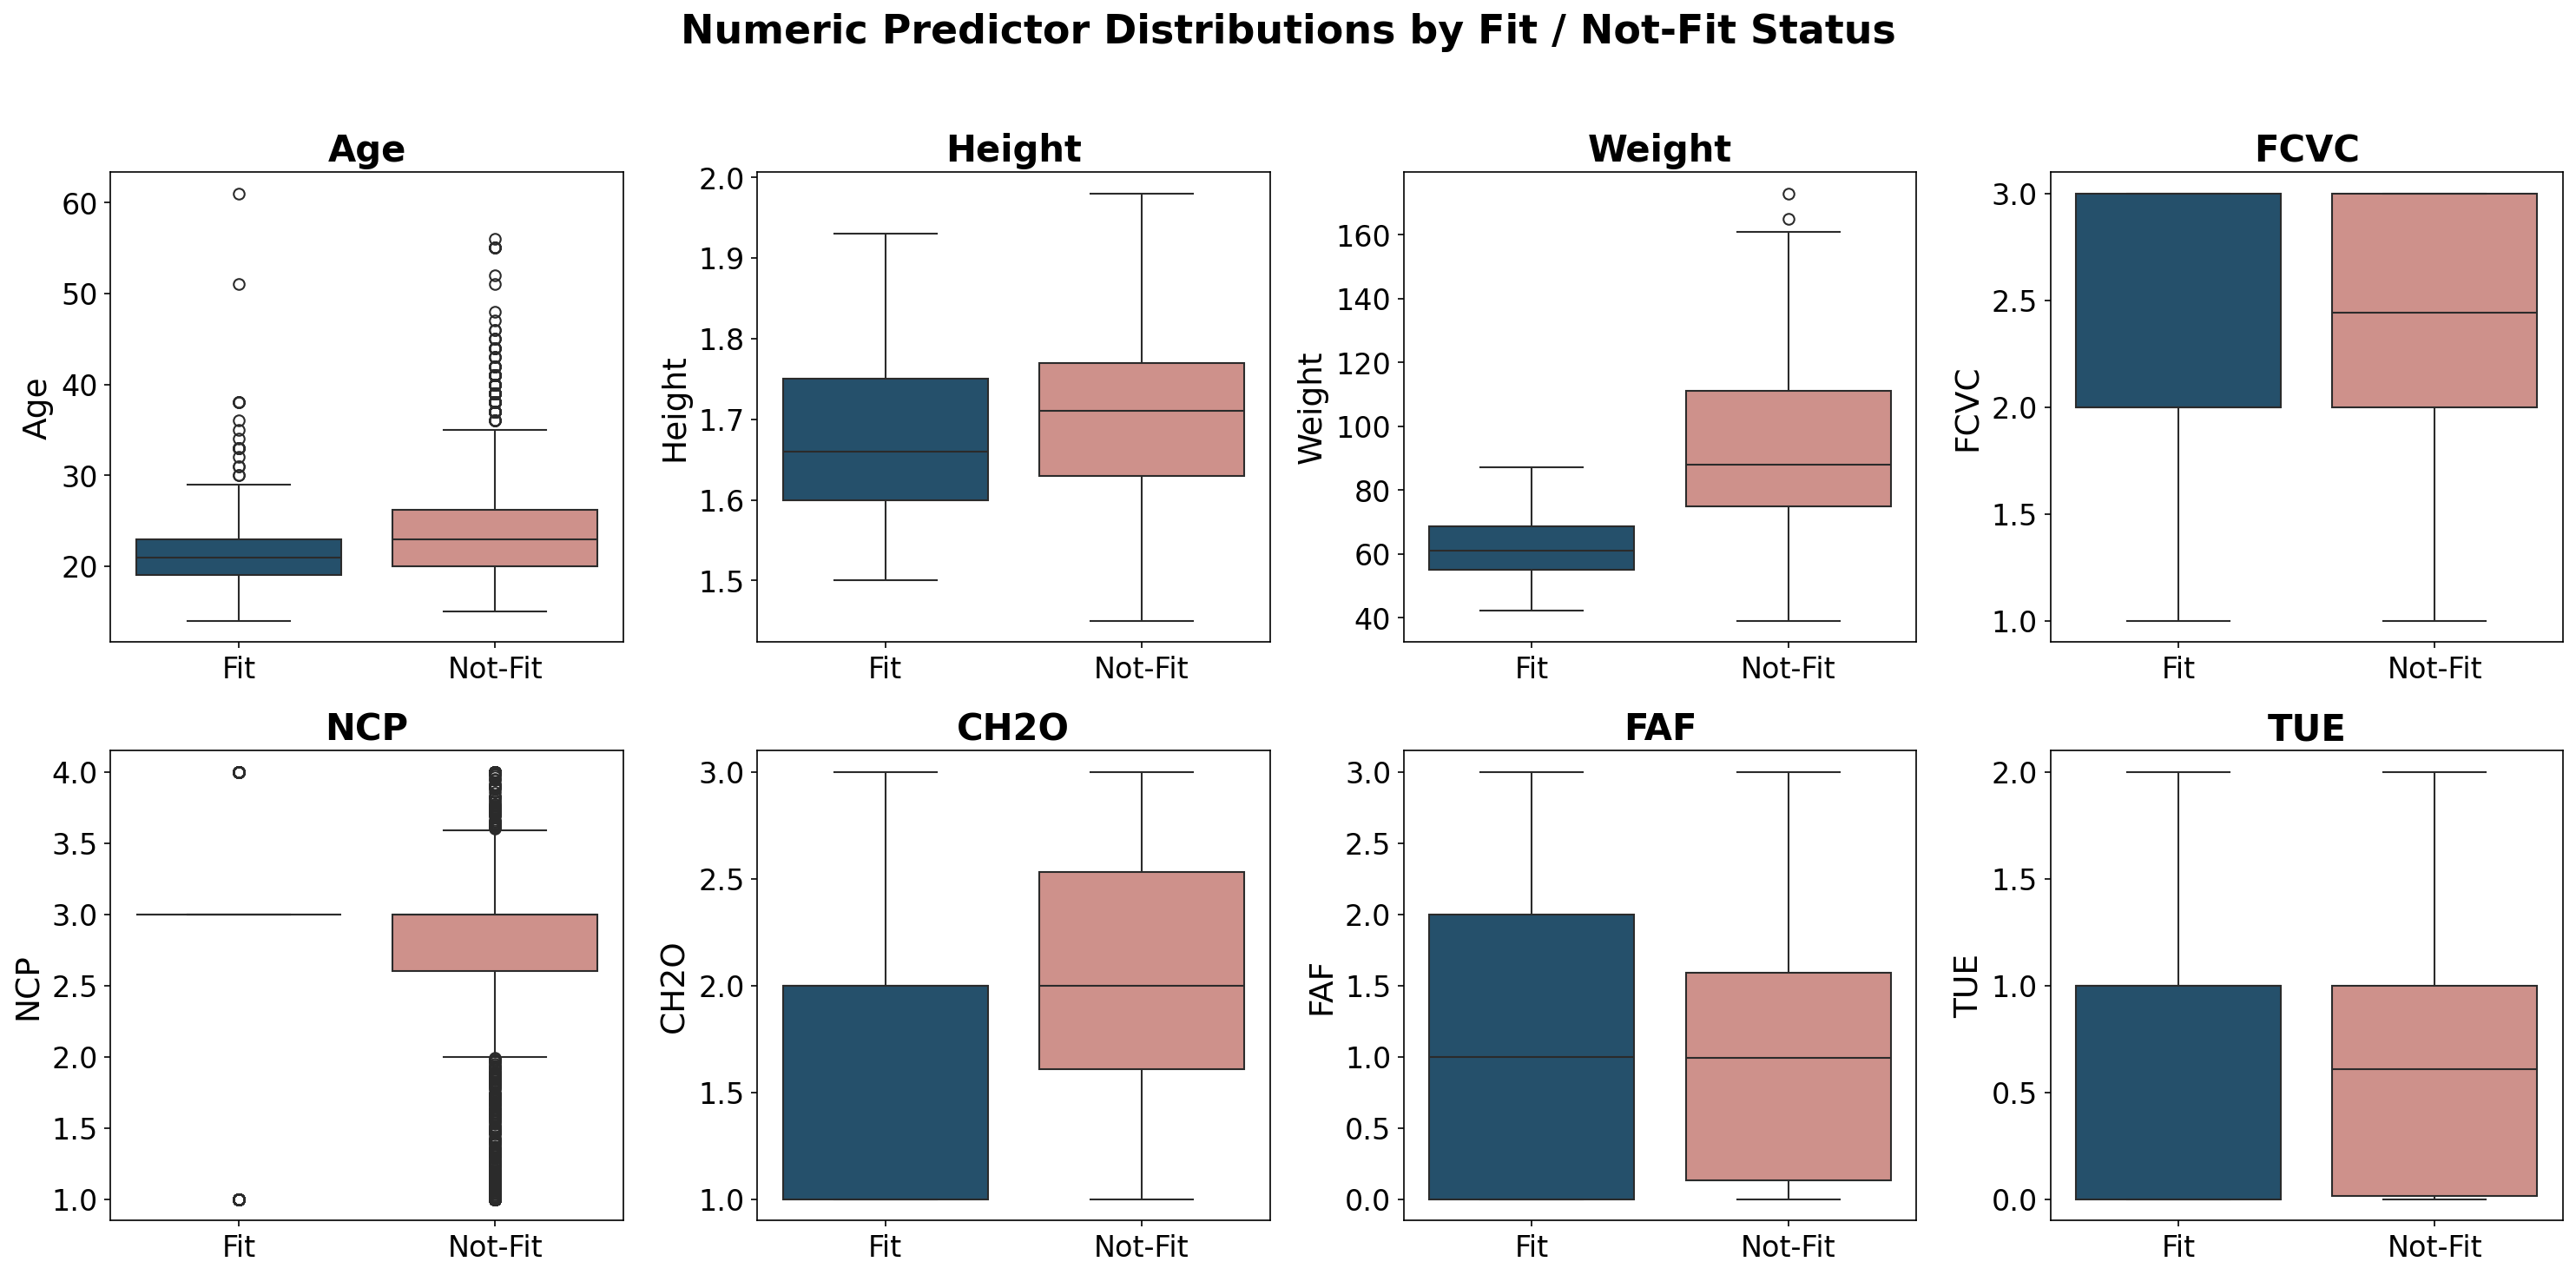

In [5]:
numeric_vars = ["Age", "Height", "Weight", "FCVC", "NCP", "CH2O", "FAF", "TUE"]

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for ax, var in zip(axes, numeric_vars):
    sns.boxplot(data=df, x="is_fit", y=var, hue="is_fit", palette=PALETTE,
                ax=ax, legend=False, order=["Fit", "Not-Fit"])
    ax.set_title(var, fontweight="bold", fontsize=20)
    ax.set_xlabel("")
    ax.set_ylabel(var, fontsize=18)
    ax.tick_params(axis="both", labelsize=16)

fig.suptitle("Numeric Predictor Distributions by Fit / Not-Fit Status", fontsize=22, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("fig4_eda_numeric_boxplots.png", bbox_inches="tight")
plt.show()

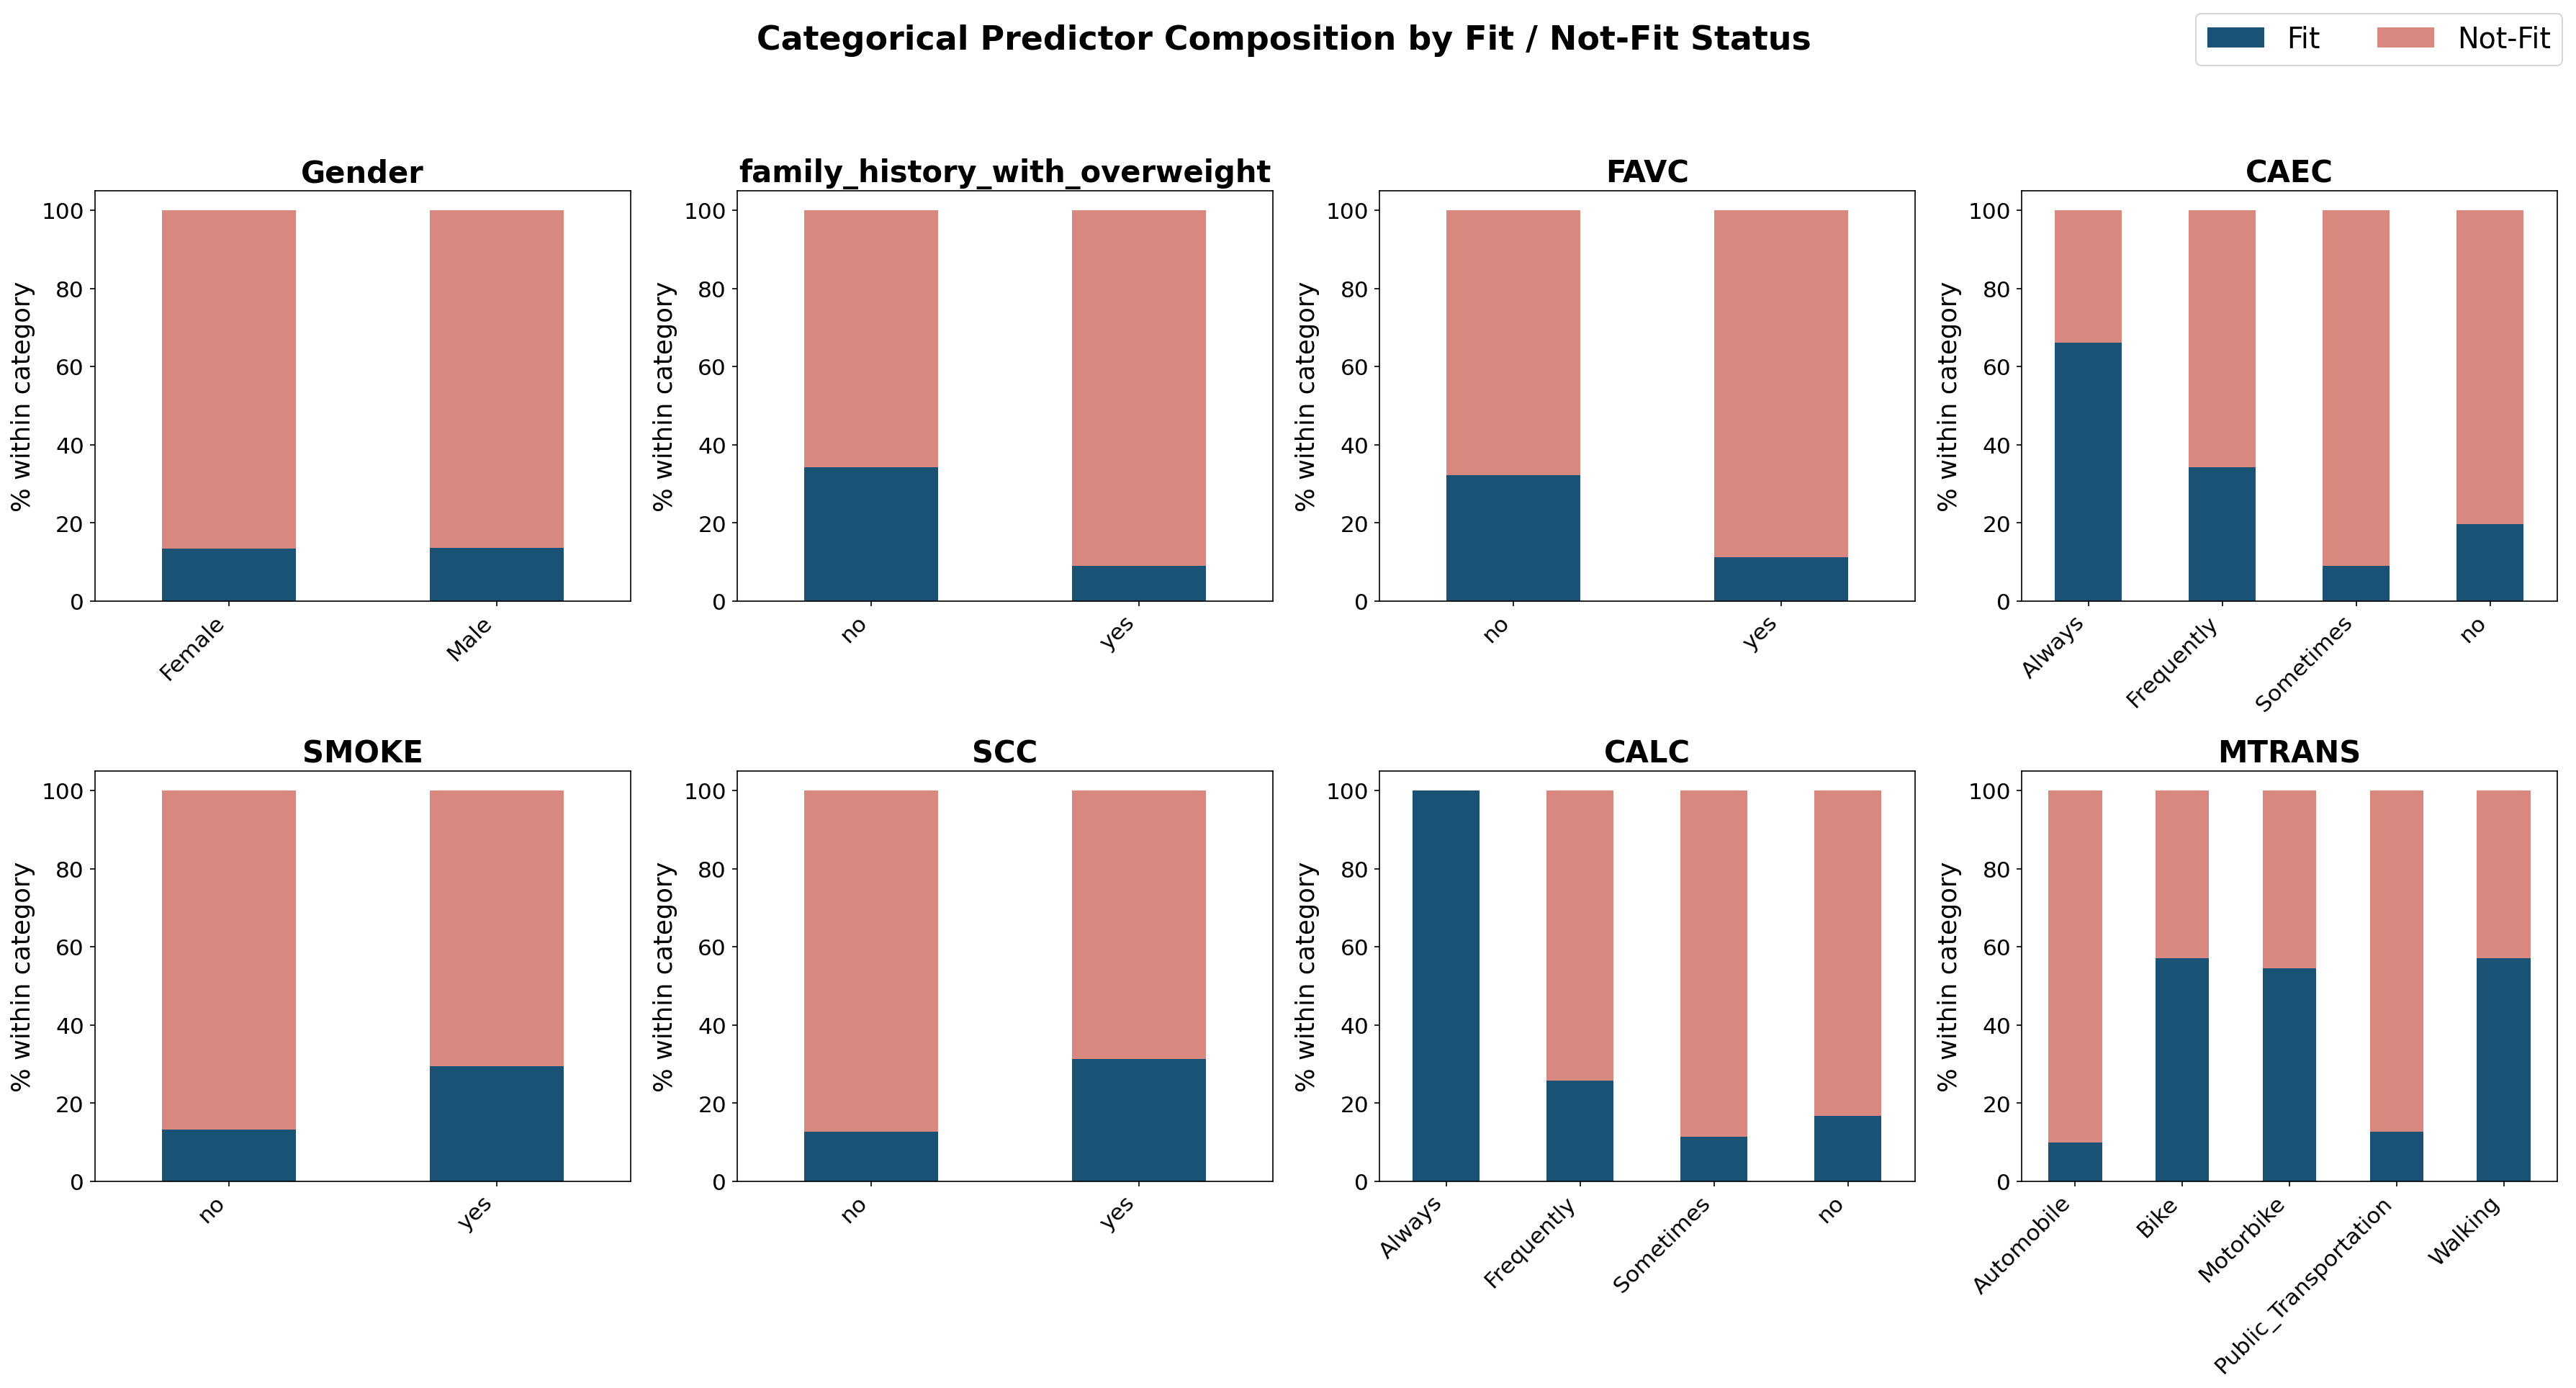

In [6]:
categorical_vars = ["Gender", "family_history_with_overweight", "FAVC",
                     "CAEC", "SMOKE", "SCC", "CALC", "MTRANS"]

fig, axes = plt.subplots(2, 4, figsize=(24, 13))
axes = axes.flatten()

for ax, var in zip(axes, categorical_vars):
    ct = pd.crosstab(df[var], df["is_fit"], normalize="index") * 100
    ct = ct[["Fit", "Not-Fit"]]
    ct.plot(kind="bar", stacked=True, ax=ax, color=[PALETTE["Fit"], PALETTE["Not-Fit"]], legend=False)
    ax.set_title(var, fontweight="bold", fontsize=20)
    ax.set_xlabel("")
    ax.set_ylabel("% within category", fontsize=17)
    ax.tick_params(axis="y", labelsize=15)
    ax.tick_params(axis="x", labelsize=15, rotation=45)
    for label in ax.get_xticklabels():
        label.set_ha("right")

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2, fontsize=19, frameon=True)
fig.suptitle("Categorical Predictor Composition by Fit / Not-Fit Status", fontsize=22, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.94])
fig.savefig("fig4_eda_categorical_bars.png", bbox_inches="tight")
plt.show()